# Advanced Analytics

This notebook performs advanced mutual fund analytics including:
- Historical VaR and CVaR
- Rolling Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Fund Recommendation Engine
- Sector HHI Concentration Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Historical VaR and CVaR Analysis

VaR measures the maximum expected loss at a 95% confidence level.

CVaR measures the average loss beyond the VaR threshold.

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [3]:
risk_report = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    if len(returns) > 30:

        var95 = np.percentile(returns,5)

        cvar95 = returns[
            returns <= var95
        ].mean()

        risk_report.append(
            [fund,var95,cvar95]
        )

var_cvar_df = pd.DataFrame(
    risk_report,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [4]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

## Rolling 90-Day Sharpe Ratio

Rolling Sharpe measures risk-adjusted performance over time.

In [5]:
top5 = (
    nav.groupby("amfi_code")["daily_return"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

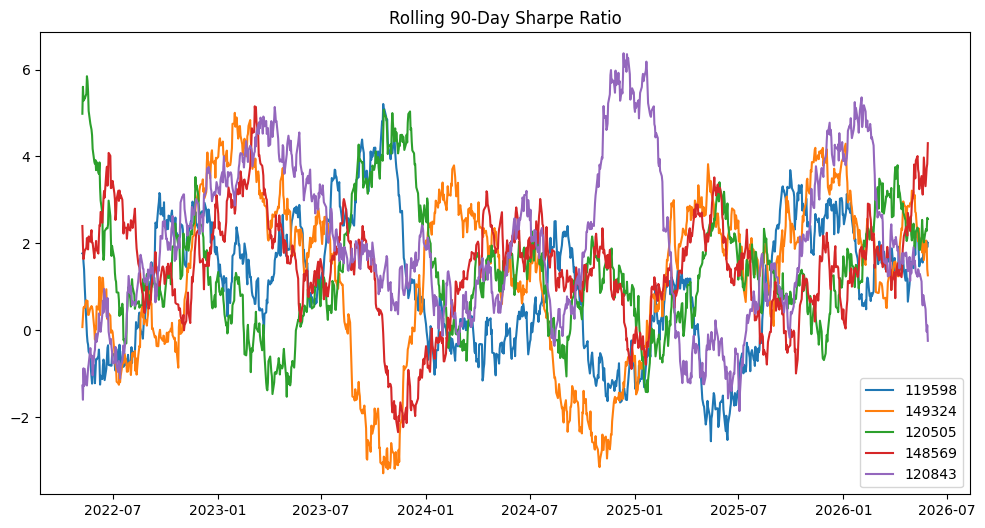

<Figure size 640x480 with 0 Axes>

In [7]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.show()
plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

In [ ]:
## Investor Cohort Analysis

Investors are grouped based on their first transaction year.

In [31]:
holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [32]:
import numpy as np

hhi = (
    holdings.groupby("amfi_code")
    ["weight_pct"]
    .apply(
        lambda x: np.sum((x/100)**2)
    )
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [34]:
hhi.sort_values(
    "HHI",
    ascending=True
).head(10)

,amfi_code,HHI
17,119598,0.107349
16,119552,0.108011
9,118634,0.108358
20,120504,0.108674
14,119095,0.109605
5,102886,0.114693
33,149324,0.118677
15,119551,0.118716
8,118633,0.121461
24,120842,0.127439


## Advanced Insights

### Insight 1
Funds with the highest VaR and CVaR values exhibit the greatest downside risk and are more vulnerable during market corrections.

### Insight 2
Rolling 90-Day Sharpe Ratios show that top-performing funds maintain superior risk-adjusted returns over long periods.

### Insight 3
Investor cohorts from recent years contribute a significant share of total SIP investments, indicating growing retail participation.

### Insight 4
SIP continuity analysis identifies investors with average gaps exceeding 35 days as At-Risk, highlighting potential churn.

### Insight 5
Funds with higher HHI values are more concentrated in a few sectors, while lower HHI funds provide better diversification benefits.